# **Fine-Tune ViT for Image Classification with Hugging Face Transformers**


The Vision Transformer (ViT) is a deep learning model that adapts the Transformer architecture, originally developed for NLP, to handle image data. ViT splits an image into fixed-size patches, linearly embeds them, and processes them as a sequence of tokens similar to words in text. It captures long-range dependencies and global context effectively, often outperforming convolutional neural networks (CNNs) in various vision tasks when pre-trained on large datasets. ViT models are particularly known for their scalability and high accuracy in image classification.

Reference : https://huggingface.co/blog/fine-tune-vit

## Load dataset

In [1]:
from datasets import load_dataset
import numpy as np

In [5]:
#load dataset
ds = load_dataset('/kaggle/input/glasses-classification-dataset/train')
ds

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 104
    })
})

In [8]:
#sample
print("dataset features :" ,ds["train"].features)
print("sample :",ds["train"][25] )

dataset features : {'image': Image(mode=None, decode=True, id=None), 'label': ClassLabel(names=['glasses', 'noglasses'], id=None)}
sample : {'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=159x155 at 0x7B3376DDA710>, 'label': 0}


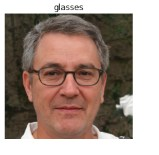

In [10]:
#show image 
image=ds["train"][25]["image"]
image

**Visual samples**

Filter:   0%|          | 0/104 [00:00<?, ? examples/s]

Filter:   0%|          | 0/104 [00:00<?, ? examples/s]

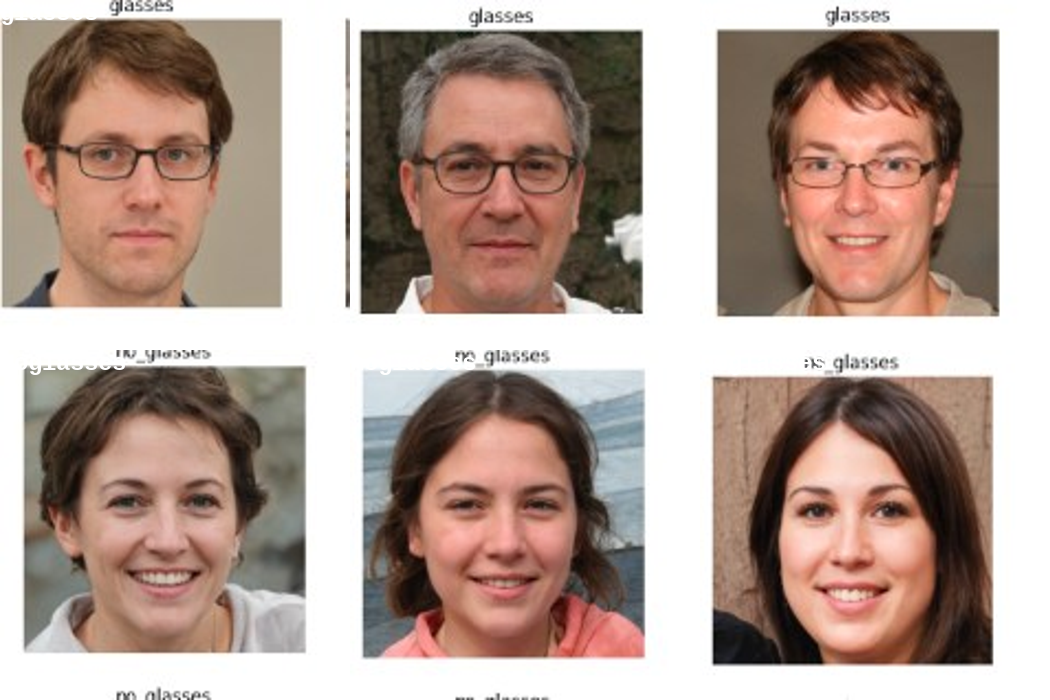

In [18]:
from transformers.utils.dummy_vision_objects import ImageGPTFeatureExtractor
import random
from PIL import ImageDraw, ImageFont, Image

def show_examples(ds, seed: int = 1234, examples_per_class: int = 3, size=(350, 350)):

    w, h = size
    labels = ds['train'].features['label'].names
    grid = Image.new('RGB', size=(examples_per_class * w, len(labels) * h))
    draw = ImageDraw.Draw(grid)
    font = ImageFont.truetype("/usr/share/fonts/truetype/liberation/LiberationMono-Bold.ttf", 24)

    for label_id, label in enumerate(labels):

        # Filter the dataset by a single label, shuffle it, and grab a few samples
        ds_slice = ds['train'].filter(lambda ex: ex['label'] == label_id).shuffle(seed).select(range(examples_per_class))

        # Plot this label's examples along a row
        for i, example in enumerate(ds_slice):
            image = example['image']
            idx = examples_per_class * label_id + i
            box = (idx % examples_per_class * w, idx // examples_per_class * h)
            grid.paste(image.resize(size), box=box)
            draw.text(box, label, (255, 255, 255), font=font)

    return grid

show_examples(ds, seed=random.randint(0,50), examples_per_class=3)

## Loading ViT Feature Extractor

In [22]:
from transformers import ViTFeatureExtractor,ViTImageProcessor

model_name_or_path = 'google/vit-base-patch16-224-in21k' #"google/vit-base-patch32-384"
feature_extractor = ViTFeatureExtractor.from_pretrained(model_name_or_path)
processor = ViTImageProcessor.from_pretrained(model_name_or_path)
print("feature_extractor :",feature_extractor)

print("processor :",processor)

feature_extractor : ViTFeatureExtractor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTFeatureExtractor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

processor : ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



In [23]:
feature_extractor(image, return_tensors='pt')

{'pixel_values': tensor([[[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]]])}

## Processing the Dataset

**Example**

In [26]:
def process_example(example):
    inputs = feature_extractor(example['image'], return_tensors='pt')
    inputs['labels'] = example['label']
    return inputs

In [27]:
process_example(ds['train'][0])

{'pixel_values': tensor([[[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]]]), 'labels': 0}

transform the ladaset

In [28]:
def transform(example_batch):
    # Take a list of PIL images and turn them to pixel values
    inputs = feature_extractor([x for x in example_batch['image']], return_tensors='pt')

    # Don't forget to include the labels!
    inputs['labels'] = example_batch['label']
    return inputs



In [41]:
# split up training into training + validation
splits = ds["train"].train_test_split(test_size=0.15)
train_ds = splits['train']
val_ds = splits['test']

In [56]:
pre_train_ds = train_ds.with_transform(transform)
print("prepared_ds shape :", pre_train_ds.shape)
pre_val_ds = val_ds.with_transform(transform)
print("prepared_ds shape :", Pre_val_ds.shape)

prepared_ds shape : (88, 2)
prepared_ds shape : (16, 2)


In [57]:
#sample
print(pre_train_ds[12:16])

{'pixel_values': tensor([[[[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],

         [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],

         [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000

## Training and Evaluation

### Define our data collator

Batches are coming in as lists of dicts, so we just unpack + stack those into batch tensors.

We return a batch `dict` from our `collate_fn` so we can simply `**unpack` the inputs to our model later. ✨

In [80]:
import torch

def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.tensor([x['labels'] for x in batch])
    }

In [65]:
#Not mandatory
#from transformers import DefaultDataCollator
#collate_fn = DefaultDataCollator(return_tensors="pt")

### Define an evaluation metric

In [36]:
!pip install evaluate
from evaluate import load

metric = load("accuracy")
def compute_metrics(p):
    return metric.compute(predictions=np.argmax(p.predictions, axis=1), references=p.label_ids)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.0 MB/s eta 0:00:0000:01


label to Id

In [81]:
labels = ds["train"].features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label
    
    
print("lebel2id :",label2id)
print("id2label :",id2label)

lebel2id : {'glasses': 0, 'noglasses': 1}
id2label : {0: 'glasses', 1: 'noglasses'}


Load pretrain model

In [82]:
from transformers import ViTForImageClassification



model = ViTForImageClassification.from_pretrained(
    model_name_or_path,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


set training argument

output_dir="./vit-base-ASL_v1":

This sets the directory where all outputs from training (like model checkpoints, logs, etc.) will be saved

per_device_train_batch_size=16:
Defines the batch size per GPU/CPU during training. Setting it to 16 means each device processes 16 samples per step.

eval_strategy="steps":
This specifies how often to run evaluation. Setting it to "steps" means evaluation will happen after a specified number of steps (determined by eval_steps).

num_train_epochs=2:
The total number of epochs (full passes through the training data) for which the model will be trained.

fp16=True:
Enables mixed-precision training using 16-bit floating-point arithmetic. This speeds up training and reduces memory usage, particularly helpful if you’re using a GPU that supports it.

save_steps=100:
The model checkpoint is saved every 100 steps. Useful for restoring the model if training is interrupted or for experimenting with intermediate checkpoints.

eval_steps=10:
Sets evaluation frequency to every 10 steps. During training, every 10 steps, the model will be evaluated on the validation set

logging_steps=10:
Specifies how often training metrics (like loss) should be logged. Here, the model logs metrics every 10 steps.

learning_rate=2e-4:
Sets the initial learning rate for the optimizer. A learning rate of 2e-4 is relatively high for transformers, possibly chosen to speed up convergence.

save_total_limit=2:
Limits the number of checkpoints stored to the two most recent ones. This helps manage disk space, keeping only the latest two checkpoints

remove_unused_columns=False:
Keeps all columns in the dataset, even those not directly used by the model, which can be helpful for logging or debugging.

push_to_hub=False:
Specifies whether to push the trained model to the Hugging Face Model Hub. Setting this to False keeps it local.

report_to='tensorboard':
Sends logs to TensorBoard for visualization. You can track metrics like loss and accuracy in real time using TensorBoard.

load_best_model_at_end=True:
After training, this option loads the best model found during training (based on evaluation metrics) instead of the final one. This is useful for ensuring that the model used for inference or deployment is the best one encountered during training.

In [1]:
from transformers import TrainingArguments

training_args = TrainingArguments(
  output_dir="./vit-base-beans-demo-v5",
  per_device_train_batch_size=16,
  evaluation_strategy="steps",
  num_train_epochs=4,
  fp16=True,
  save_steps=100,
  eval_steps=100,
  logging_steps=10,
  learning_rate=2e-4,
  save_total_limit=2,
  remove_unused_columns=False,
  push_to_hub=False,
  report_to='tensorboard',
  load_best_model_at_end=True,
)

/opt/conda/lib/python3.10/site-packages/transformers/training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


### Training the model

In [84]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=pre_train_ds,
    eval_dataset=pre_val_ds,
    tokenizer=feature_extractor,
)

In [85]:
train_results = trainer.train()
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()

Step,Training Loss,Validation Loss


***** train metrics *****
  epoch                    =        4.0
  total_flos               = 25403853GF
  train_loss               =     0.1595
  train_runtime            = 0:05:25.29
  train_samples_per_second =      1.082
  train_steps_per_second   =      0.074


### Evaluatiuon

In [95]:
test_ds = load_dataset('/kaggle/input/glasses-classification-dataset/validate')
test_ds

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 40
    })
})

In [96]:
pre_test_ds = test_ds["train"].with_transform(transform)
print("prepared_ds shape :", pre_test_ds.shape)

prepared_ds shape : (40, 2)


In [101]:
pre_test_ds.features

{'image': Image(mode=None, decode=True, id=None),
 'label': ClassLabel(names=['glasses', 'noglasses'], id=None)}

In [102]:
metrics = trainer.evaluate(pre_test_ds)
trainer.log_metrics("eval", metrics)
trainer.save_metrics("eval", metrics)

***** eval metrics *****
  epoch                   =        4.0
  eval_accuracy           =        1.0
  eval_loss               =     0.0285
  eval_runtime            = 0:00:11.27
  eval_samples_per_second =      3.549
  eval_steps_per_second   =      0.444


## Inferences

In [86]:
from transformers import ViTForImageClassification  # or the appropriate model class

# Load the model from the output directory
model = ViTForImageClassification.from_pretrained("./vit-base-")
model.eval()


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fe

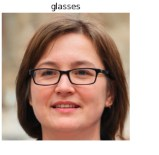

/opt/conda/lib/python3.10/site-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


ImageClassifierOutput(loss=None, logits=tensor([[ 1.9020, -1.7796]]), hidden_states=None, attentions=None)
Predicted class: glasses


In [87]:
import torch
from PIL import Image
from IPython.display import display
from transformers import AutoFeatureExtractor

# Load an image and feature extractor (preprocessing for vision models)
image = Image.open("/kaggle/input/glasses-classification-dataset/test/row-1-column-7.jpg")
# Display the image
display(image)


feature_extractor = AutoFeatureExtractor.from_pretrained("./vit-base-beans-demo-v5")

# Preprocess the image
inputs = feature_extractor(images=image, return_tensors="pt")

# Get predictions
with torch.no_grad():
    outputs = model(**inputs)
    print(outputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)

print(f"Predicted class: {id2label[predictions.item()]}")
